In [3]:
!pip install qiskit qiskit-aer --upgrade


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: C:\Users\bhara\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



Task 1: Original Circuit (H → CNOT → CZ → SWAP)
        ┌───┐            ░ ┌─┐   
   q_0: ┤ H ├──■───■──X──░─┤M├───
        └───┘┌─┴─┐ │  │  ░ └╥┘┌─┐
   q_1: ─────┤ X ├─■──X──░──╫─┤M├
             └───┘       ░  ║ └╥┘
   c: 2/════════════════════╬══╬═
                            ║  ║ 
meas: 2/════════════════════╩══╩═
                            0  1 
Measurement Counts: {'11 00': 516, '00 00': 508}


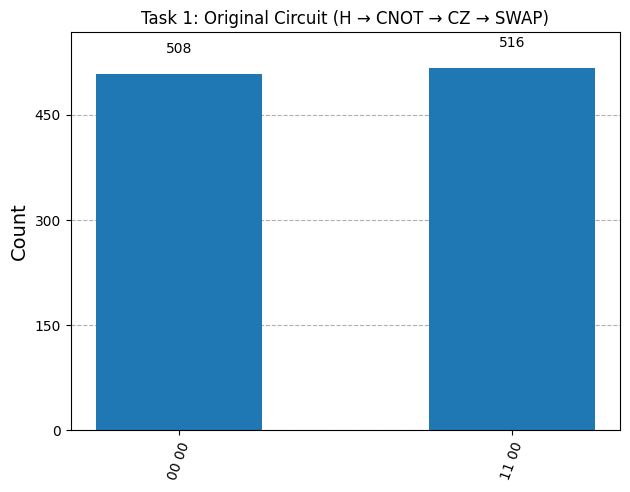


Task 2: Control/Target Variation
             ┌───┐       ░ ┌─┐   
   q_0: ─────┤ X ├─■──X──░─┤M├───
        ┌───┐└─┬─┘ │  │  ░ └╥┘┌─┐
   q_1: ┤ H ├──■───■──X──░──╫─┤M├
        └───┘            ░  ║ └╥┘
   c: 2/════════════════════╬══╬═
                            ║  ║ 
meas: 2/════════════════════╩══╩═
                            0  1 
Measurement Counts: {'00 00': 514, '11 00': 510}


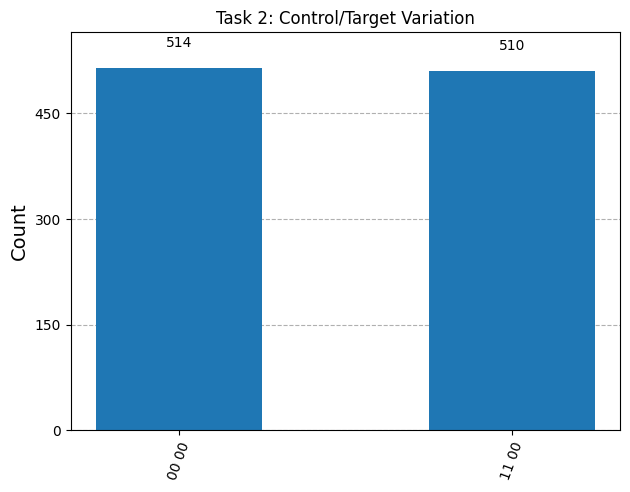


Task 3: Without SWAP Gate
        ┌───┐         ░ ┌─┐   
   q_0: ┤ H ├──■───■──░─┤M├───
        └───┘┌─┴─┐ │  ░ └╥┘┌─┐
   q_1: ─────┤ X ├─■──░──╫─┤M├
             └───┘    ░  ║ └╥┘
   c: 2/═════════════════╬══╬═
                         ║  ║ 
meas: 2/═════════════════╩══╩═
                         0  1 
Measurement Counts: {'00 00': 514, '11 00': 510}


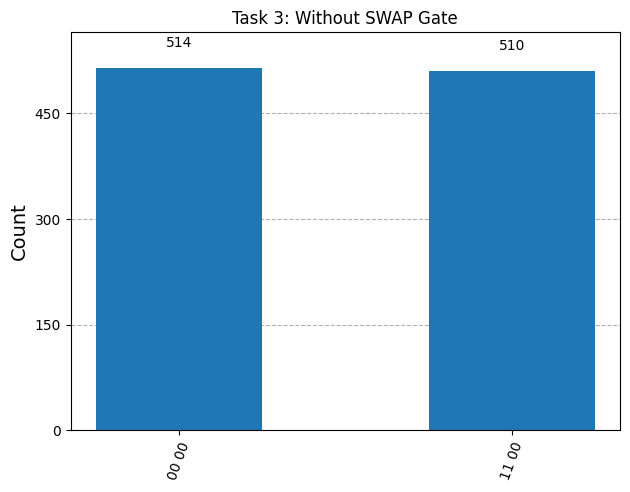


Task 4: Added Hadamard on Second Qubit
        ┌───┐            ░ ┌─┐   
   q_0: ┤ H ├──■───■──X──░─┤M├───
        ├───┤┌─┴─┐ │  │  ░ └╥┘┌─┐
   q_1: ┤ H ├┤ X ├─■──X──░──╫─┤M├
        └───┘└───┘       ░  ║ └╥┘
   c: 2/════════════════════╬══╬═
                            ║  ║ 
meas: 2/════════════════════╩══╩═
                            0  1 
Measurement Counts: {'10 00': 246, '00 00': 259, '11 00': 255, '01 00': 264}


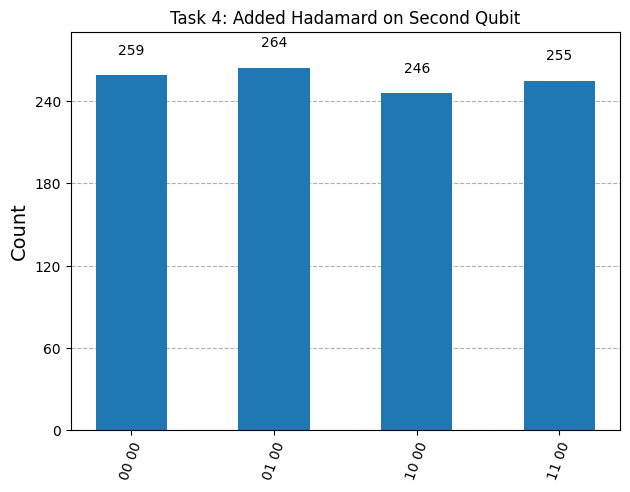

In [4]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Initialize simulator
sim = AerSimulator()

def run_and_plot(qc, title):
    compiled = transpile(qc, sim)
    result = sim.run(compiled, shots=1024).result()
    counts = result.get_counts()
    print(f"\n{title}")
    print(qc.draw())
    print("Measurement Counts:", counts)
    plot_histogram(counts)
    plt.title(title)
    plt.show()

# --- Task 1: Original Circuit ---
qc1 = QuantumCircuit(2, 2)
qc1.h(0)
qc1.cx(0, 1)
qc1.cz(0, 1)
qc1.swap(0, 1)
qc1.measure_all()
run_and_plot(qc1, "Task 1: Original Circuit (H → CNOT → CZ → SWAP)")

# --- Task 2: Control/Target Variation ---
qc2 = QuantumCircuit(2, 2)
qc2.h(1)
qc2.cx(1, 0)  # swapped control & target
qc2.cz(1, 0)
qc2.swap(0, 1)
qc2.measure_all()
run_and_plot(qc2, "Task 2: Control/Target Variation")

# --- Task 3: Gate Removal (No SWAP) ---
qc3 = QuantumCircuit(2, 2)
qc3.h(0)
qc3.cx(0, 1)
qc3.cz(0, 1)
qc3.measure_all()
run_and_plot(qc3, "Task 3: Without SWAP Gate")

# --- Task 4: Add Another Hadamard ---
qc4 = QuantumCircuit(2, 2)
qc4.h(0)
qc4.h(1)
qc4.cx(0, 1)
qc4.cz(0, 1)
qc4.swap(0, 1)
qc4.measure_all()
run_and_plot(qc4, "Task 4: Added Hadamard on Second Qubit")